## The Future Is Not a Feature: A Look-Ahead Bias-Free Evaluation Framework for Startup Success Prediction through Machine Learning

In [1]:
%load_ext autoreload
%autoreload 2

import os
from dotenv import load_dotenv 
import yaml

import pandas as pd
import polars as pl
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

from src.preprocessing import preprocessDataset,getCompleteDatasetWithTimeWindow, getCompleteDatasetWithoutTimeWindow
from src.utils import plot_correlation_heatmap, to_tensors, get_probs, plot_shap_comparison, compute_wilcoxon_table, set_seed,compare_metrics


from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from src.models.MLP import MLP


from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score, roc_auc_score)
import wandb
import shap
import matplotlib.pyplot as plt 


import scipy.integrate
if not hasattr(np, 'trapz'):
    np.trapz = scipy.integrate.trapezoid

load_dotenv()

with open('config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)


timeWindow=int(config['time_window'])

lastYear=int(config['last_year'])

shap_store = {}
metrics_store = {}

/home/giulio-casti/Scrivania/UNICA/DOTTORATO/startup-survival-TabPFN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset creation

Include all the steps of the feature and target engineering starting from the panel dataset. 

The original initial panel cannot be released. In _data/raw/panel_example.csv_  there is an example with few records.

Loading of the initial panel and university ranking

In [ ]:
# initialPanel = pl.read_csv(config['paths']['raw_dataset'], null_values=["NA"])

# university_ranking_path = config['paths']['raw_university_ranking']

## Dataset with time window (no look-ahead bias)
Already available in _data/processed/dataset_window.csv_

In [ ]:
# datasetWithTimeWindow = getCompleteDatasetWithTimeWindow(initialPanel,timeWindow,lastYear)

# dataset_window = preprocessDataset(datasetWithTimeWindow,university_ranking_path)

# dataset_window.write_csv(config["paths"]["dataset_window"])

# print("Dataset with time window saved to:", config['paths']['dataset_window'])

## Dataset without time window (with look ahead bias)
Already available in _data/processed/dataset_nowindow.csv_

In [ ]:
# # need to re-run the previous cell to get dataset_window before running the following code, to ensure that 
# # the firm in the dataset without time window are the same as those in the dataset with time window

# datasetWithNoTimeWindow = getCompleteDatasetWithoutTimeWindow(initialPanel,dataset_window)

# dataset_nowindow = preprocessDataset(datasetWithNoTimeWindow,university_ranking_path,flag_no_time_window=True)

# # to ensure that the firm in the dataset without time window are the same as those in the dataset with time window, we select only those that are present in the dataset with time window (we must keep the same columns and rows in all the experiments to make them comparable)
# dataset_nowindow = dataset_nowindow.select(dataset_window.columns)

# dataset_nowindow.write_csv(config["paths"]["dataset_nowindow"])

# print("Dataset without time window saved to:", config['paths']['dataset_nowindow'])

## Multiclass dataset with time window (no look-ahead bias)
Already available in _data/processed/dataset_window_multi.csv_

In [ ]:
# datasetWithTimeWindow = getCompleteDatasetWithTimeWindow(initialPanel,timeWindow,lastYear)

# dataset_window = preprocessDataset(datasetWithTimeWindow,university_ranking_path,multiclass=True)

# dataset_window.write_csv(config["paths"]["dataset_window_multi"])

# print("Dataset with time window saved to:", config['paths']['dataset_window_multi'])

## Dataset selection:
(choose one)

Bias controlled experiment

In [2]:
dataset = pd.read_csv(config["paths"]["dataset_window"])
tag="window"

In [3]:
from tabpfn_client import init, TabPFNClassifier
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

# Load an example dataset
ids = dataset['CompanyID'] 
X = dataset.drop(['CompanyID', 'Target'],axis=1)
y = dataset['Target']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)

# 3. Applichiamo il bilanciamento ai dati
X, y = rus.fit_resample(X, y)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, stratify=y, random_state=config['random_seed'])

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Train set shape: (11664, 45)
Test set shape: (7776, 45)


In [4]:
# Use it like any sklearn model
model = TabPFNClassifier(
      thinking_mode=True,
      thinking_effort="high",     
      thinking_timeout_s=600,        # budget fit: 10 min
      thinking_metric="roc_auc",
      random_state=config['random_seed']     
  )
model.fit(X_train, y_train)

Found existing access token, reusing it for authentication.

00:00 Fitting... |

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '508c849ca37c43f2b3af23f2d6a3ae05'}),
                 random_state=12, thinking_effort='high',
                 thinking_metric='roc_auc', thinking_mode=True,
                 thinking_timeout_s=600)

In [5]:

# Get predictions
preds_test = model.predict(X_test)
probs_test = model.predict_proba(X_test)[:, 1]

labels_train = y_train
labels_test = y_test

00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:24 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:25 Predicting... Done!


In [6]:
acc       = accuracy_score(labels_test, preds_test)
precision = precision_score(labels_test, preds_test, zero_division=0)
recall    = recall_score(labels_test, preds_test, zero_division=0)
f1        = f1_score(labels_test, preds_test, zero_division=0)

fpr, tpr, _ = roc_curve(labels_test, probs_test)
roc_auc = auc(fpr, tpr)


print(f"Accuracy: {acc:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")

Accuracy: 0.73
Precision: 0.73
Recall: 0.72
F1 Score: 0.73
ROC AUC: 0.80


In [ ]:
tn, fp, fn, tp = confusion_matrix(labels_test, preds_test).ravel()

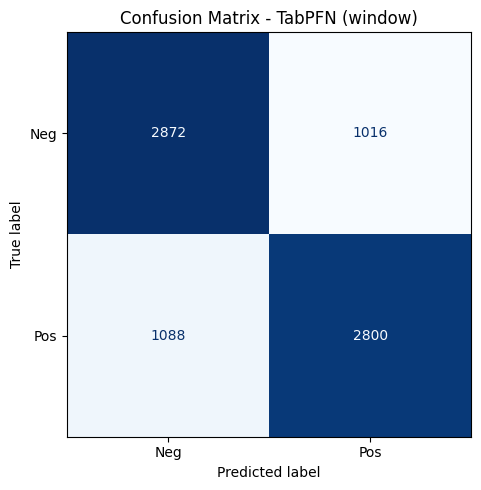

In [7]:
# Confusion matrix - TabPFN
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(labels_test, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Neg", "Pos"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix - TabPFN ({tag})")
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SHAP per TabPFN (versione client / API remota)
#
# TabPFN NON è un modello ad albero né lineare: va spiegato come "black box".
# Avvolgiamo predict_proba (probabilità della classe positiva) e usiamo un
# explainer model-agnostic (KernelExplainer), come si fa per l'MLP.
#
# ⚠️ COSTO API: il client TabPFN gira via API remota, quindi ogni valutazione
#    SHAP è una chiamata di rete. KernelExplainer valuta il modello su circa
#    (N_BACKGROUND × NSAMPLES) righe per OGNI istanza spiegata. I valori sotto
#    sono volutamente piccoli: alzali con cautela e controlla i limiti dell'API.
# ─────────────────────────────────────────────────────────────────────────────
set_seed(config['random_seed'])

N_BACKGROUND = 20     # righe di riferimento (background) prese dal train
N_EXPLAIN    = 50     # istanze di test da spiegare
NSAMPLES     = 100    # coalizioni per istanza (qualità della stima vs costo API)

feature_names = X.columns.tolist()

# Background e campione da spiegare: numpy imputato, coerente col fit (X_*_imp)
background = shap.sample(X_train_imp, N_BACKGROUND, random_state=config['random_seed'])
explainer_sample = X_test_imp[:N_EXPLAIN]

# Funzione black-box: probabilità della classe positiva
def tabpfn_predict_proba(x):
    return model.predict_proba(x)[:, 1]

explainer   = shap.KernelExplainer(tabpfn_predict_proba, background)
shap_values = explainer.shap_values(explainer_sample, nsamples=NSAMPLES)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    explainer_sample,
    feature_names=feature_names,
    show=False
)
plt.title(f"SHAP - TabPFN ({tag})")
plt.tight_layout()
plt.show()

# # Salva per il confronto cross-experiment, coerente con shap_store/make_train
# if tag is not None:
#     shap_store[("tabpfn", tag)] = {
#         "shap_values": np.asarray(shap_values),
#         "explainer_sample": explainer_sample,
#     }

No window experiment (look-ahead bias)

In [ ]:
dataset = pd.read_csv(config["paths"]["dataset_nowindow"])
tag="nowindow"

Multiclass dataset

In [ ]:
dataset = pd.read_csv(config["paths"]["dataset_window_multi"])
tag="multi"

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Creiamo un dataset fittizio multiclasse sbilanciato
# Esempio: Classi A (maggioritaria), B (media), C (minoritaria)
df = dataset

# 2. Contiamo i valori
target_counts = df["Target"].value_counts()

# 3. Configurazione del Grafico a Torta Multiclasse
plt.figure(figsize=(8, 8))

# Usiamo una palette di colori predefinita di Matplotlib (es. 'Set2' o 'Pastel1')
# ideale per gestire più classi elegantemente
colors = plt.get_cmap("Set2").colors

plt.pie(
    target_counts,
    labels=target_counts.index,  # Prende direttamente i nomi delle classi
    autopct="%1.1f%%",  # Mostra la percentuale
    startangle=90,  # Parte dall'alto
    colors=colors[: len(target_counts)],  # Adatta il numero di colori alle classi
    wedgeprops={"edgecolor": "white", "linewidth": 2},  # Linea bianca per separare le fette
)

# 4. Aggiungiamo una legenda laterale per maggiore chiarezza
plt.legend(
    target_counts.index, title="Categorie", loc="center left", bbox_to_anchor=(1, 0.5)
)

plt.title(
    "Distribuzione del Target (Multiclass Imbalance)", fontsize=14, weight="bold"
)
plt.tight_layout()  # Evita che la legenda venga tagliata
plt.show()

No Team experiment

In [ ]:
dataset = pd.read_csv(config["paths"]["dataset_window"])
dataset = dataset.drop(columns= [
    "Total_People",
    "WorkExp_Idx_Mean",
    "Highest_Degree_Mean",
    "Total_Founders",
    "Percent_Females",
    "Avg_Earliest_Year",
    "HasTop50Institute",
    "Is_Eco",
    "Is_Eng",
    "Is_NS",
    "Is_Hum",
    "Is_SS",
    "Is_Med",
    "Is_Law",
    "Is_IT",
    "WorkExperienceIndex_CEO",
    "Gender_CEO_Female"
])
tag="noteam"

No Competitors experiment

In [ ]:
dataset = pd.read_csv(config["paths"]["dataset_window"])
dataset = dataset.drop(columns=['SimilarityScoreMean', 'N_Competitors', 'Same_Country'])
tag="nocompetitors"

Feature correlation

In [ ]:
corr_matrix = plot_correlation_heatmap(dataset)

## Split, Imputation and Scaling

Run for each experiment

In [ ]:
ids = dataset['CompanyID'] 
X = dataset.drop(['CompanyID', 'Target'],axis=1)
y = dataset['Target']

# Split: 60% train, 20% validation (threshold tuning), 20% test (final evaluation)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=config['test_size'], stratify=y, random_state=config['random_seed'])
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=config['random_seed'])

imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)


scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print(f"Total: {len(y)} | Train: {len(y_train)} | Validation: {len(y_val)} | Test: {len(y_test)}")

## Sweep creation

In [ ]:

entity=os.getenv("entity")
project=os.getenv("project")

# Initialize a new sweep
sweep_id = wandb.sweep(config["sweep_settings"],entity=entity, project=project)


Definition of the training function to be called by wandb agent.

It will be called multiple times by the wandb agent, each time with a different set of hyperparameters defined in the sweep configuration.

The function trains the specified model, evaluates it on the validation and test sets, logs metrics and plots to Weights & Biases, and computes SHAP values for interpretability.

The _tag_ parameter is used to differentiate between different dataset versions (e.g., with or without time window) when storing SHAP values for later comparison.

In [ ]:
def make_train(tag=None):
    def train():
        with wandb.init():
            wandb_config = wandb.config

            # Reproducibility: seed Python, NumPy, PyTorch (CPU+CUDA), cuDNN.
            # Sklearn / LightGBM models also get a random_state explicitly below.
            set_seed(config['random_seed'])
            
            # --- RANDOM FOREST ---
            if wandb_config.model_type == "rf":
                model = RandomForestClassifier(
                    n_estimators= wandb_config.rf_n_estimators, 
                    max_depth= wandb_config.rf_max_depth,  
                    min_samples_leaf= wandb_config.rf_min_samples_leaf,
                    max_features='log2',
                    class_weight='balanced',  
                    random_state=config['random_seed']
                )

                model.fit(X_train_imp, y_train)
                preds_train = model.predict(X_train_imp)
                preds_val = model.predict(X_val_imp)
                preds_test = model.predict(X_test_imp)
                probs_train = model.predict_proba(X_train_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                labels_train = y_train
                labels_val = y_val
                labels_test = y_test

            # --- LGBM ---
            elif wandb_config.model_type == "lgb":
                # Ratio for scale_pos_weight (80/20 -> 4) 
                ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1]) 
                
                model = lgb.LGBMClassifier(
                    n_estimators= wandb_config.lgb_n_estimators, 
                    learning_rate= wandb_config.learning_rate, 
                    max_depth= wandb_config.lgb_max_depth, 
                    scale_pos_weight=ratio,  
                    min_child_weight= wandb_config.min_child_weight, 
                    subsample= wandb_config.subsample,                
                    colsample_bytree= wandb_config.colsample_bytree, 
                    reg_alpha= wandb_config.reg_alpha, 
                    reg_lambda= wandb_config.reg_lambda,
                    random_state=config['random_seed'],
                )

                model.fit(X_train_imp, y_train)
                preds_train = model.predict(X_train_imp)
                preds_val = model.predict(X_val_imp)
                preds_test = model.predict(X_test_imp)
                probs_train = model.predict_proba(X_train_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                labels_train = y_train
                labels_val = y_val
                labels_test = y_test

            # --- DECISION TREE ---
            elif wandb_config.model_type == "dt":
                model = DecisionTreeClassifier(
                    max_depth=wandb_config.dt_max_depth,
                    min_samples_leaf=wandb_config.dt_min_samples_leaf,
                    min_samples_split=wandb_config.dt_min_samples_split,
                    criterion=wandb_config.dt_criterion,
                    class_weight='balanced',
                    random_state=config['random_seed']
                )

                model.fit(X_train_imp, y_train)
                preds_train = model.predict(X_train_imp)
                preds_val = model.predict(X_val_imp)
                preds_test = model.predict(X_test_imp)
                probs_train = model.predict_proba(X_train_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                labels_train = y_train
                labels_val = y_val
                labels_test = y_test

            # --- LOGISTIC REGRESSION  ---
            elif wandb_config.model_type == "lr":
                model = LogisticRegression(
                    C=wandb_config.lr_C,  
                    penalty=wandb_config.lr_penalty,
                    solver='saga',
                    class_weight='balanced',
                    max_iter=1000,
                    random_state=config['random_seed']
                )

                model.fit(X_train_scaled, y_train)
                preds_train = model.predict(X_train_scaled)
                preds_val = model.predict(X_val_scaled)
                preds_test = model.predict(X_test_scaled)
                probs_train = model.predict_proba(X_train_scaled)[:, 1]
                probs_val = model.predict_proba(X_val_scaled)[:, 1]
                probs_test = model.predict_proba(X_test_scaled)[:, 1]

                labels_train = y_train
                labels_val = y_val
                labels_test = y_test

            elif wandb_config.model_type == "mlp":
                # ── SWEEP HYPERPARAMETERS ──
                hidden_sizes = [int(x) for x in wandb_config.hidden_sizes.split(",")] 
                mlp_lr = wandb_config.mlp_learning_rate 
                mlp_dropout = wandb_config.dropout_rate 
                mlp_wd = wandb_config.weight_decay
                BATCH_SIZE = wandb_config.batch_size 

                # ── TENSOR CONVERSION ──
                X_train_t, y_train_t = to_tensors(X_train_scaled, y_train)
                X_val_t,   y_val_t   = to_tensors(X_val_scaled,   y_val)
                X_test_t,  y_test_t  = to_tensors(X_test_scaled,  y_test)

                # ── DATALOADER ──
                # Seeded generator so that shuffle order is reproducible across runs.
                train_generator = torch.Generator()
                train_generator.manual_seed(config['random_seed'])
                train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                                        batch_size=BATCH_SIZE, shuffle=True,
                                        generator=train_generator)
                val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                                        batch_size=BATCH_SIZE)
                test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                                        batch_size=BATCH_SIZE)

                # ── MODEL, LOSS, OPTIMIZER ──
                device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

                model = MLP(
                    input_size=X_train_scaled.shape[1],
                    hidden_sizes=hidden_sizes,
                    dropout_rate=mlp_dropout,
                    batch_norm=True
                ).to(device)

                # Class weight: pos_weight = n_neg / n_pos (loss balancing)
                n_pos = y_train.sum()
                n_neg = len(y_train) - n_pos
                pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
                criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

                optimizer = torch.optim.AdamW(model.parameters(), lr=mlp_lr, weight_decay=mlp_wd)
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='max', factor=0.5, patience=5
                )
                # ── TRAINING LOOP ──
                EPOCHS = 100
                best_auc = 0.0
                patience_counter = 0
                EARLY_STOPPING_PATIENCE = 10

                # Temporary path for best model checkpoint
                _tmp_dir = os.path.join(os.getcwd(), "tmp")
                os.makedirs(_tmp_dir, exist_ok=True)
                best_model_path = os.path.join(_tmp_dir, "best_model.pt")

                for epoch in range(EPOCHS):

                    # ── Train ──
                    model.train()
                    train_loss = 0.0

                    for X_batch, y_batch in train_loader:
                        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                        optimizer.zero_grad()
                        preds = model(X_batch)
                        loss  = criterion(preds, y_batch)
                        loss.backward()
                        optimizer.step()

                        train_loss += loss.item() * len(X_batch)

                    train_loss /= len(train_loader.dataset)

                    # ── Validation ──
                    model.eval()
                    val_loss = 0.0
                    all_preds, all_labels = [], []

                    with torch.no_grad():
                        for X_batch, y_batch in val_loader:
                            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                            logits = model(X_batch)
                            loss   = criterion(logits, y_batch)
                            val_loss += loss.item() * len(X_batch)

                            probs = torch.sigmoid(logits).cpu().numpy()
                            all_preds.extend(probs)
                            all_labels.extend(y_batch.cpu().numpy())

                    val_loss /= len(val_loader.dataset)
                    val_auc   = roc_auc_score(all_labels, all_preds)
                    val_f1    = f1_score(all_labels, (np.array(all_preds) > 0.5).astype(int))

                    scheduler.step(val_auc)

                    print(f"Epoch {epoch+1:3d} | "
                        f"Train Loss: {train_loss:.4f} | "
                        f"Val Loss: {val_loss:.4f} | "
                        f"Val AUC: {val_auc:.4f} | "
                        f"Val F1: {val_f1:.4f}")

                    # ── Early Stopping + Best Model ──
                    if val_auc > best_auc:
                        best_auc = val_auc
                        patience_counter = 0
                        torch.save(model.state_dict(), best_model_path)
                    else:
                        patience_counter += 1
                        if patience_counter >= EARLY_STOPPING_PATIENCE:
                            print(f"\nEarly stopping at epoch {epoch+1}. Best AUC: {best_auc:.4f}")
                            break
                # ── EVALUATION ──
                model.load_state_dict(torch.load(best_model_path, weights_only=True))
                if os.path.exists(best_model_path):
                    os.remove(best_model_path)
                model.eval()

                probs_train, labels_train = get_probs(train_loader, model, device)
                probs_val,   labels_val   = get_probs(val_loader,   model, device)
                probs_test,  labels_test  = get_probs(test_loader,  model, device)
                preds_train = (probs_train >= 0.5).astype(int)
                preds_val   = (probs_val   >= 0.5).astype(int)
                preds_test  = (probs_test  >= 0.5).astype(int)




            # Test set metrics
            acc       = accuracy_score(labels_test, preds_test)
            acc_train = accuracy_score(labels_train, preds_train)
            precision = precision_score(labels_test, preds_test, zero_division=0)
            recall    = recall_score(labels_test, preds_test, zero_division=0)
            f1        = f1_score(labels_test, preds_test, zero_division=0)
            f1_train  = f1_score(labels_train, preds_train, zero_division=0)
            f1_val    = f1_score(labels_val, preds_val, zero_division=0)

            # ROC Curve (test set)
            fpr, tpr, _ = roc_curve(labels_test, probs_test)
            roc_auc = auc(fpr, tpr)

            fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
            ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
            ax_roc.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
            ax_roc.set_xlim([0.0, 1.0])
            ax_roc.set_ylim([0.0, 1.05])
            ax_roc.set_xlabel('False Positive Rate')
            ax_roc.set_ylabel('True Positive Rate')
            ax_roc.set_title(f'ROC - {wandb_config.model_type.upper()}')
            ax_roc.legend(loc='lower right')
            ax_roc.grid(alpha=0.3)

            # Precision-Recall Curve (test set)
            prec_curve, rec_curve, _ = precision_recall_curve(labels_test, probs_test)
            ap = average_precision_score(labels_test, probs_test)

            fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
            ax_pr.plot(rec_curve, prec_curve, color='green', lw=2, label=f'PR curve (AP = {ap:.3f})')
            ax_pr.set_xlim([0.0, 1.0])
            ax_pr.set_ylim([0.0, 1.05])
            ax_pr.set_xlabel('Recall')
            ax_pr.set_ylabel('Precision')
            ax_pr.set_title(f'Precision-Recall - {wandb_config.model_type.upper()}')
            ax_pr.legend(loc='upper right')
            ax_pr.grid(alpha=0.3)

            wandb.log({
                "accuracy_train": acc_train,
                "F1_train": f1_train,
                "F1_val": f1_val,
                "accuracy": acc,
                "F1": f1,
                "precision": precision,
                "recall": recall,
                "AUC": roc_auc,
                "average_precision": ap,
                "roc_curve": wandb.Image(fig_roc),
                "pr_curve": wandb.Image(fig_pr),
            })
            plt.close(fig_roc)
            plt.close(fig_pr)

            print(f"AUC: {roc_auc:.3f} | AP: {ap:.3f}")


            print(classification_report(labels_test, preds_test))


            wandb.sklearn.plot_confusion_matrix(labels_test, preds_test, ["Neg", "Pos"])

            # Persist metrics for later cross-experiment comparison (parallel to shap_store).
            if tag is not None:
                metrics_store[(wandb_config.model_type, tag)] = {
                    "accuracy_train":    acc_train,
                    "F1_train":          f1_train,
                    "F1_val":            f1_val,
                    "accuracy":          acc,
                    "F1":                f1,
                    "precision":         precision,
                    "recall":            recall,
                    "AUC":               roc_auc,
                    "average_precision": ap,
                }

            # Re-seed before SHAP so that the stochastic SHAP estimators
            # (shap.sample, KernelExplainer) give the same values across runs.
            set_seed(config['random_seed'])

            # Data consistent with the model used
            if wandb_config.model_type in ["rf", "lgb", "dt"]:
                explainer_sample = X_test.iloc[:1000]          # non scaled — RF, LGBM, DT fitted on X_train_imp
            elif wandb_config.model_type == "lr":
                explainer_sample = X_test_scaled[:1000]         # scaled — LR fitted on X_train_scaled
            else:
                explainer_sample = X_test_scaled[:1000]         # scaled — MLP fitted on X_train_scaled

            if wandb_config.model_type in ["rf", "lgb", "dt"]:
                explainer = shap.TreeExplainer(model)
                shap_result = explainer.shap_values(explainer_sample)

                if isinstance(shap_result, list):
                    shap_values = shap_result[1]
                elif hasattr(shap_result, 'shape') and len(shap_result.shape) == 3:
                    shap_values = shap_result[:, :, 1]
                else:
                    shap_values = shap_result

            elif wandb_config.model_type == "lr":
                explainer = shap.LinearExplainer(model, X_train_scaled)
                shap_values = explainer.shap_values(explainer_sample)

            else:
                def mlp_predict(x):
                    model.eval()
                    with torch.no_grad():
                        t = torch.tensor(x, dtype=torch.float32).to(device)
                        logits = model(t)
                        probs = torch.sigmoid(logits).cpu().numpy().flatten()
                    return probs

                background = shap.sample(X_train_scaled, 30, random_state=config['random_seed'])
                explainer = shap.KernelExplainer(mlp_predict, background)
                shap_values = explainer.shap_values(explainer_sample, nsamples=1000)

            # Summary plot 
            plt.figure(figsize=(10, 6))
            shap.summary_plot(
                shap_values,
                explainer_sample,
                feature_names=X.columns.tolist(),
                show=False
            )
            wandb.log({"shap_summary_plot": wandb.Image(plt)})
            plt.close()
            
            if(tag is not None):
                shap_store[(wandb_config.model_type, tag)] = {
                    "shap_values": np.asarray(shap_values),
                    "explainer_sample": explainer_sample,
                }
    return train
                

# Experiment

## Sweep start

_tag_ is usefull for shap comparison between models, change with "nowindow" if you are running the no window experiment. 

_number_of_runs_ indicate the number of runs for the sweep. 

 - Set 70 and set a fixed model in _config/config.yaml_ (model_type) if you want to search the best hyperparams configuration.

 - Set 5 if you want to test all the models with the best found configuration. Make sure all the models are enabled in _config/config.yaml_ model_type

The best hyperparameter configurations for each model are avaible in _config/config.yaml_ 


In [ ]:
number_of_runs = 5

wandb.agent(sweep_id, function=make_train(tag), count=number_of_runs)

## Metrics comparison across experiments

For each model, the table below compares the metrics of the `window` experiment against another experiment (`nowindow`, `nocompetitors`, `noteam`). 

Values are rounded to 2 decimals; `diff_%` is the percent change of the other experiment relative to `window` (`(other - window) / window * 100`).

Run all the experiments to populate `metrics_store` before executing the cells below.

### Comparison across window and nowindow experiments
You need to run both the "window" and "nowindow" runs before executing the following code, to ensure that shap_store and metrics_store contains the necessary data for both configurations

In [ ]:
df_cmp_nowindow = compare_metrics(metrics_store, "window", "nowindow")
print(df_cmp_nowindow.to_string(index=False))

In [ ]:
fig = plot_shap_comparison(shap_store)
plt.show()

In [ ]:
df_wilcoxon = compute_wilcoxon_table(shap_store)
print(df_wilcoxon.to_string(index=False))

### Comparison across window and noteam experiments
You need to run both the "window" and "noteam" runs before executing the following code, to ensure that shap_store and metrics_store contains the necessary data for both configurations

In [ ]:
df_cmp_noteam = compare_metrics(metrics_store, "window", "noteam")
print(df_cmp_noteam.to_string(index=False))

### Comparison across window and nocompetitors experiments
You need to run both the "window" and "nocompetitors" runs before executing the following code, to ensure that shap_store and metrics_store contains the necessary data for both configurations

In [ ]:
df_cmp_nocompetitors = compare_metrics(metrics_store, "window", "nocompetitors")
print(df_cmp_nocompetitors.to_string(index=False))